In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example - System identification with particle MCMC




We are once again looking at the system-identification problem, but this time we use particle marginal Metropolis--Hastings to sample the parameter posterior. The particle filter supplies an unbiased estimate $\widehat Z(\theta)$ of the likelihood. The algorithm is:

+ Initialize $\theta^{(0)}$
+ Construct the particle approximation $\{\{(w_t^i, x_t^i)\}_{t=1}^T\}_{i=1}^N$ 
+ For i = 1, .., I:
    + Propose a new parameter $\theta' \sim q(\cdot \mid \theta^{(i-1)})$
    + Run a new particle filter at $\theta'$ and compute $\widehat Z(\theta')$
    + Compute the acceptance probability

    $$
    \alpha = \min\left(1, \frac{\widehat Z(\theta')p(\theta')q(\theta^{(i-1)} \mid \theta')}{\widehat Z(\theta^{(i-1)})p(\theta^{(i-1)})q(\theta' \mid \theta^{(i-1)})}\right)
    $$

    + Accept $\theta'$ with probability $\alpha$


In [3]:
import importlib.util
import json
import subprocess
import sys
from importlib import metadata

DAX_COMMIT = "65b4c1c21ad3b8add4ca0d104bb388ab38632590"
required_packages = {"diffrax": "diffrax", "optax": "optax", "blackjax": "blackjax", "seaborn": "seaborn"}
missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])

try:
    direct_url = metadata.distribution("dax").read_text("direct_url.json")
    installed_dax_commit = json.loads(direct_url or "{}").get("vcs_info", {}).get("commit_id")
except metadata.PackageNotFoundError:
    installed_dax_commit = None

if installed_dax_commit != DAX_COMMIT:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--no-deps", "--force-reinstall",
        f"git+https://github.com/PredictiveScienceLab/dax.git@{DAX_COMMIT}",
    ])

In [4]:
import time
import equinox as eqx
import jax
import jax.random as jr
import jax.numpy as jnp
import dax

jax.config.update("jax_enable_x64", True)
key = jr.PRNGKey(0)

## Duffing oscillator

We use the same stochastic state-space model as in the filtering, smoothing, and EM examples:

$$
\begin{aligned}
dX_{1,t} &= X_{2,t}\,dt + \sigma_x\,dW_{1,t}, \\
dX_{2,t} &= \left[\gamma\cos(\omega t)-\delta X_{2,t}-\alpha X_{1,t}-\beta X_{1,t}^3\right]dt + \sigma_v\,dW_{2,t},\\
Y_n &= X_{1,t_n}+s\varepsilon_n, \qquad \varepsilon_n\sim\mathcal N(0,1).
\end{aligned}
$$

The Brownian motions and observation errors are independent. We keep $\gamma$, $\sigma_x$, $\sigma_v$, and the initial-state distribution fixed and infer $\theta=(\alpha,\beta,\delta,s)$. Thus $s$ is the observation-noise standard deviation, not a process-diffusion parameter.

In [5]:
# Define the right-hand side, deterministic part of the Duffing oscillator
class DuffingControl(dax.ControlFunction):

    omega: jax.Array

    def __init__(self, omega):
        self.omega = jnp.array(omega)
    
    def _eval(self, t):
        # This is to avoid training the parameter
        omega = jax.lax.stop_gradient(self.omega)
        return jnp.cos(omega * t)

    
class Duffing(dax.StochasticDifferentialEquation):

    alpha: jax.Array
    beta: jax.Array
    delta: jax.Array

    gamma: jax.Array
    log_sigma_x: jax.Array
    log_sigma_v: jax.Array

    @property
    def sigma_x(self):
        return jnp.exp(self.log_sigma_x)

    @property
    def sigma_v(self):
        return jnp.exp(self.log_sigma_v)

    def __init__(self, alpha, beta, gamma, delta, sigma_x, sigma_v, u):
        super().__init__(control_function=u)
        self.alpha = jnp.array(alpha)
        self.beta = jnp.array(beta)
        self.delta = jnp.array(delta)

        self.gamma = jnp.array(gamma)
        self.log_sigma_x = jnp.log(sigma_x)
        self.log_sigma_v = jnp.log(sigma_v)
    
    def drift(self, x, u):
        # We won't train gamma
        gamma = jax.lax.stop_gradient(self.gamma)
        return jnp.array([x[1], -self.delta * x[1] - self.alpha * x[0] - self.beta * x[0] ** 3 + gamma * u])
    
    def diffusion(self, x, u):
        # We won't train sigma_x and sigma_v
        sigma_x = jax.lax.stop_gradient(self.sigma_x)
        sigma_v = jax.lax.stop_gradient(self.sigma_v)
        return jnp.array([sigma_x, sigma_v])

We will first define the true system parameters and generate our noisy data.

In [6]:
# True parameters
omega = 1.2
alpha = -1.0
beta = 1.0
delta = 0.3
gamma = 0.5
sigma_x = 0.01
sigma_v = 0.05
u = DuffingControl(omega)
true_sde = Duffing(alpha, beta, gamma, delta, sigma_x, sigma_v, u)

# True initial conditions
true_x0 = jnp.array([1.0, 0.0])

# Observation model
observation_function = dax.SingleStateSelector(0)
# Observation standard deviation
s = 0.1
true_likelihood = dax.GaussianLikelihood(s, observation_function)

# Generate synthetic data
t0 = 0.0
t1 = 40.0
dt = 0.1
key, path_key, observation_key = jr.split(key, 3)
sol = true_sde.sample_path(path_key, t0, t1, true_x0, dt=dt, dt0=0.05)
xs = sol.ys
ts = sol.ts
us = u(ts)
keys = jr.split(observation_key, xs.shape[0])
ys = true_likelihood.sample(xs, us, keys)

# Training data: transition n uses u(t_n) and is scored by y(t_{n+1}).
num_train_transitions = 200
us_train = us[:num_train_transitions]
ys_train = ys[1:num_train_transitions + 1]

We need a prior over the parameter coordinates and an observation likelihood. For continuity with the preceding example, we use an improper flat prior in $(\alpha,\beta,\delta,\log s)$; this choice is meaningful only when the resulting posterior is proper. Working with $\log s$ keeps $s$ positive.

In [7]:
# Prior
class SSMPrior(dax.Prior):

    def log_prob(self, theta):
        # Improper flat prior in alpha, beta, delta, and log(s).
        return 0.0

    def sample(self, key):
        return None

# Likelihood
class GaussianLikelihood(dax.Likelihood):

    log_s: jax.Array

    @property
    def s(self):
        return jnp.exp(self.log_s)

    def __init__(self, s):
        self.log_s = jnp.log(jnp.asarray(s))

    def _log_prob(self, y, x, u):
        return -0.5 * jnp.sum(((y - x[0]) / self.s) ** 2) - self.log_s
    
    def _sample(self, x, u, key):
        return x[0] + self.s * jr.normal(key)

Let's initialize the parameters $\theta^{(0)}$ for our chain to start from. Try adjusting the initial parameters and see how the chain behaves.

In [8]:
# Start a model from the wrong parameters
alpha_0 = -1.5
beta_0 = 1.5
delta_0 = 0.5
s_0 = 1.0

# The chain uses log(s), so this positive initial value is transformed below.

Construct a state-space model from each proposed parameter vector. Only the four entries of `theta` are proposed; the initial-state distribution and process-noise amplitudes remain fixed.

In [9]:
# Place the parameters in a dictionary
theta = {
    'alpha': alpha_0,
    'beta': beta_0,
    'delta': delta_0,
    'log_s': jnp.log(s_0),
}

# Create a state-space model from the parameters
def ssm_from_theta(theta):
    return dax.StateSpaceModel(
        dax.DiagonalGaussian(
            jnp.array([0.0, 0.0]),
            jnp.array([2.0, 2.0])),
        dax.EulerMaruyama(Duffing(theta['alpha'], theta['beta'], gamma, theta['delta'], sigma_x, sigma_v, u), dt=dt),
        GaussianLikelihood(jnp.exp(theta['log_s']))
    )

We are now set up to run particle MCMC. The particle count controls the noise in the likelihood estimate, while the proposal scale controls the acceptance and mixing of the parameter chain.

In [10]:
# Particle MCMC hyperparameters
num_particles = 1000
proposal_scale = 0.01
num_iters = 10000

class IndependentInitParticleMCMC(dax.ParticleMCMC):
    """Particle MCMC with independent initial-filter and chain streams."""

    @eqx.filter_jit
    def run(self, theta, us, ys, num_steps, key):
        init_key, chain_key = jr.split(key)
        log_prior = self.prior.log_prob(theta)
        ssm = self.ssm_from_theta(theta)
        _, log_L = self.filter.filter(ssm, us, ys, init_key)
        state = (theta, log_L, log_prior, chain_key, us, ys)
        state, results = jax.lax.scan(
            lambda scan_state, _: self.step(scan_state),
            state,
            jnp.arange(num_steps),
        )
        return state, results


prior = SSMPrior()
filter = dax.BootstrapFilter(num_particles=num_particles)
mcmc = IndependentInitParticleMCMC(prior, filter, proposal_scale, ssm_from_theta)

print('Running MCMC')

# Track the amount of time it takes to run the MCMC
mcmc_start = time.time()

final_state, (accept, log_Ls, thetas) = mcmc.run(theta, us_train, ys_train, num_iters, key)

mcmc_end = time.time()

print(f'MCMC took {mcmc_end - mcmc_start:.2f} seconds')
print(f'Acceptance rate: {jnp.mean(accept):.3f}')

Running MCMC


MCMC took 217.46 seconds
Acceptance rate: 0.222


First inspect the estimated log-likelihood trace and the reported acceptance rate. These are useful debugging signals, but neither one establishes convergence of the parameter chain.

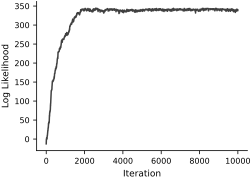

In [11]:
fig, ax = new_figure(size="half_standard")
ax.plot(log_Ls, color="0.25")
ax.set_xlabel('Iteration')
ax.set_ylabel('Log Likelihood')
finalize_axes(keep_box=False)
plt.show()

Trace plots show how the chain moves through parameter space and can reveal sticking or slow exploration.

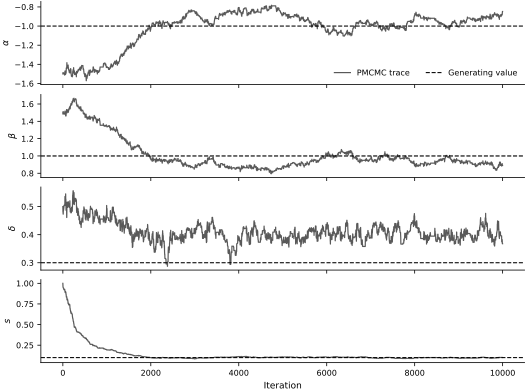

In [12]:
fig, ax = new_figure(size="full_tall", nrows=4, ncols=1, sharex=True)
trace_style = {"color": "0.35", "linewidth": 1.2}
truth_style = {"color": "black", "linestyle": "--", "linewidth": 1.1}

ax[0].plot(thetas['alpha'], label='PMCMC trace', **trace_style)
ax[0].axhline(alpha, label='Generating value', **truth_style)
ax[0].set_ylabel(r'$\alpha$')
ax[0].legend(loc='lower right', ncol=2)

ax[1].plot(thetas['beta'], **trace_style)
ax[1].axhline(beta, **truth_style)
ax[1].set_ylabel(r'$\beta$')

ax[2].plot(thetas['delta'], **trace_style)
ax[2].axhline(delta, **truth_style)
ax[2].set_ylabel(r'$\delta$')

ax[3].plot(jnp.exp(thetas['log_s']), **trace_style)
ax[3].axhline(s, **truth_style)
ax[3].set_xlabel('Iteration')
ax[3].set_ylabel(r'$s$')

finalize_axes(keep_box=False)
plt.show()

For an illustrative summary, discard the explicitly labeled warmup segment and plot marginal histograms. A release-quality posterior analysis should run multiple chains and report rank-normalized $\widehat R$, bulk and tail effective sample sizes, and Monte Carlo standard errors before interpreting these histograms.

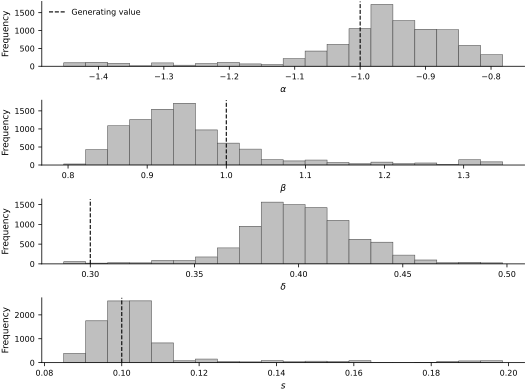

In [13]:
# Do the histograms of the parameters
warmup = int(num_iters / 10)
alpha_keep = thetas['alpha'][warmup:]
beta_keep = thetas['beta'][warmup:]
delta_keep = thetas['delta'][warmup:]
s_keep = jnp.exp(thetas['log_s'][warmup:])

fig, ax = new_figure(size="full_tall", nrows=4, ncols=1)
hist_style = {"bins": 20, "facecolor": "0.75", "edgecolor": "0.25", "linewidth": 0.5}
truth_style = {"color": "black", "linestyle": "--", "linewidth": 1.1}

ax[0].hist(alpha_keep, **hist_style)
ax[0].axvline(alpha, label='Generating value', **truth_style)
ax[0].set_xlabel(r'$\alpha$')
ax[0].set_ylabel('Frequency')
ax[0].legend(loc='upper left')

ax[1].hist(beta_keep, **hist_style)
ax[1].axvline(beta, **truth_style)
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('Frequency')

ax[2].hist(delta_keep, **hist_style)
ax[2].axvline(delta, **truth_style)
ax[2].set_xlabel(r'$\delta$')
ax[2].set_ylabel('Frequency')

ax[3].hist(s_keep, **hist_style)
ax[3].axvline(s, **truth_style)
ax[3].set_xlabel(r'$s$')
ax[3].set_ylabel('Frequency')

finalize_axes(keep_box=False)
plt.show()

This short single-chain calculation is a computational demonstration, not a validated posterior analysis. Particle MCMC is substantially more expensive than the preceding EM point estimate because every proposal runs a particle filter, but it can represent parameter uncertainty once its Monte Carlo diagnostics are satisfactory. Experiment with the particle count and proposal scale, then run multiple chains before asking whether the apparent posterior concentration reflects practical identifiability.